<a href="https://colab.research.google.com/github/snehasawant054-design/CSL701-CE-43_Machine-learning-lab/blob/main/Experiments/Experiment7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Student Name : sneha Baburao Sawant

Batch : CE-3


Roll Number :CE-43



Aim

To implement Principal Component Analysis (PCA) for dimensionality reduction on the Breast Cancer Wisconsin (Diagnostic) dataset, visualize the high-dimensional feature space in a reduced 2D plane, and evaluate its impact on classification performance.

## Objectives

1. To understand the concepts of dimensionality reduction, feature correlation, and Principal Component Analysis.

2. To preprocess, clean, and scale high-dimensional real-world data using StandardScaler.

3. To implement PCA using Python to compress feature dimensions from 30 continuous features down to 2 principal components.

4. To calculate and plot the explained variance ratio and cumulative explained variance.

5. To visualize the transformed 2D dataset and analyze class separability.

6. To evaluate and compare classification model performance (e.g., Logistic Regression) before and after applying PCA.

# Relevant Theory

### Support Vector Machine

Principal Component Analysis (PCA)Principal Component Analysis (PCA) is an unsupervised machine learning technique used for dimensionality reduction. It transforms a dataset containing a large set of correlated features into a smaller set of uncorrelated variables called Principal Components ($PCs$), while preserving as much data variance as possible.

Mathematical Steps:

1. Standardization: Scale each feature to have a mean of 0 ($\mu = 0$) and standard deviation of 1 ($\sigma = 1$).

2. Covariance Matrix: Compute the covariance matrix $C$ to quantify feature correlations:$$C = \frac{1}{n-1} X^T X$$

3. Eigen decomposition: Compute eigenvalues ($\lambda$) and eigenvectors ($v$) of matrix $C$:$$C v = \lambda v$$

    * Eigenvectors represent the direction of the principal axes.
    * Eigenvalues indicate the amount of variance along those axes.
4. Projection: Project original data $X$ onto top $k$ principal component directions $W$:$$X_{\text{pca}} = X \cdot W$$

###Dataset Information


1. Dataset Name: Breast Cancer Wisconsin (Diagnostic) Dataset

2. Kaggle Link: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

3. Classes: 2 binary classes (Malignant [$M$] and Benign [$B$])

4. Features: 30 continuous features computed from digitized images of fine needle aspirates (FNA) of a breast mass (e.g., radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, concavity_mean, etc.).

5. Non-Feature Columns: id (identifier) and Unnamed: 32 (empty column).

# Task 1: Import Libraries and Load Dataset

Import core Python libraries (numpy, pandas, matplotlib, seaborn, sklearn) and load data.csv obtained from Kaggle.

---

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Upload dataset
uploaded = files.upload()

# Read uploaded CSV file
filename = list(uploaded.keys())[0]
data = pd.read_csv(filename)

print("Dataset loaded successfully!")
print("Dataset shape:", data.shape)
print(data.head())

Saving archive.zip to archive.zip
Dataset loaded successfully!
Dataset shape: (569, 33)
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980

# Task 2: Explore the Dataset

Inspect missing values, view dataset summary statistics, check column data types, and inspect target class distributions (diagnosis).

In [ ]:
print("Dataset Information:")
data.info()

print("\nMissing Values:")
print(data.isnull().sum())

print("\nSummary Statistics:")
print(data.describe())

print("\nData Types:")
print(data.dtypes)

print("\nDiagnosis Distribution:")
print(data["diagnosis"].value_counts())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perim

# Task 3: Data Cleaning and Feature/Target Selection

Drop metadata columns (id and Unnamed: 32). Convert the categorical target column (diagnosis: 'M'/'B') into numerical values (1/0) and separate feature matrix $X$ (30 features) from label vector $y$.   

In [ ]:
data = data.drop(columns=["id", "Unnamed: 32"], errors="ignore")

data["diagnosis"] = data["diagnosis"].map({"M": 1, "B": 0})

X = data.drop(columns=["diagnosis"])
y = data["diagnosis"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

print("\nFeatures:")
print(X.head())

print("\nTarget:")
print(y.head())

Feature matrix shape: (569, 30)
Target vector shape: (569,)

Features:
   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   fractal_dimension_

# Task 4: Standardize Features

Apply StandardScaler to transform all 30 numeric features so they have zero mean and unit variance ($\mu=0, \sigma=1$).

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Standardization completed successfully.")
print("Shape of standardized data:", X_scaled.shape)

print("\nMean of first 5 features:")
print(X_scaled.mean(axis=0)[:5])

print("\nStandard deviation of first 5 features:")
print(X_scaled.std(axis=0)[:5])

Standardization completed successfully.
Shape of standardized data: (569, 30)

Mean of first 5 features:
[-1.37363271e-16  6.86816353e-17 -1.24875700e-16 -2.18532476e-16
 -8.36667193e-16]

Standard deviation of first 5 features:
[1. 1. 1. 1. 1.]


# Task 5: Implement PCA (30D to 2D)

Use sklearn.decomposition.PCA to reduce feature dimensions from 30 down to 2 principal components ($PC_1$ and $PC_2$).

In [ ]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("PCA completed successfully.")
print("Original dimensions:", X_scaled.shape[1])
print("Reduced dimensions:", X_pca.shape[1])

print("\nFirst 5 rows of PCA data:")
print(X_pca[:5])

PCA completed successfully.
Original dimensions: 30
Reduced dimensions: 2

First 5 rows of PCA data:
[[ 9.19283683  1.94858307]
 [ 2.3878018  -3.76817174]
 [ 5.73389628 -1.0751738 ]
 [ 7.1229532  10.27558912]
 [ 3.93530207 -1.94807157]]


# Task 6: Analyze Explained Variance Ratio

Compute and print the variance explained by $PC_1$ and $PC_2$, along with the cumulative variance retained.


In [ ]:
explained_variance = pca.explained_variance_ratio_

print("Variance explained by PC1:", explained_variance[0])
print("Variance explained by PC2:", explained_variance[1])

cumulative_variance = explained_variance.sum()

print("\nCumulative variance retained:", cumulative_variance)
print("Cumulative variance retained (%):", cumulative_variance * 100)

Variance explained by PC1: 0.44272025607526366
Variance explained by PC2: 0.18971182044033078

Cumulative variance retained: 0.6324320765155944
Cumulative variance retained (%): 63.243207651559445


# Task 7: Visualize PCA Transformed Boundary / Scatter Plot

Create a 2D scatter plot with $PC_1$ on the x-axis and $PC_2$ on the y-axis, hue-coded by tumor diagnosis (Malignant vs. Benign).

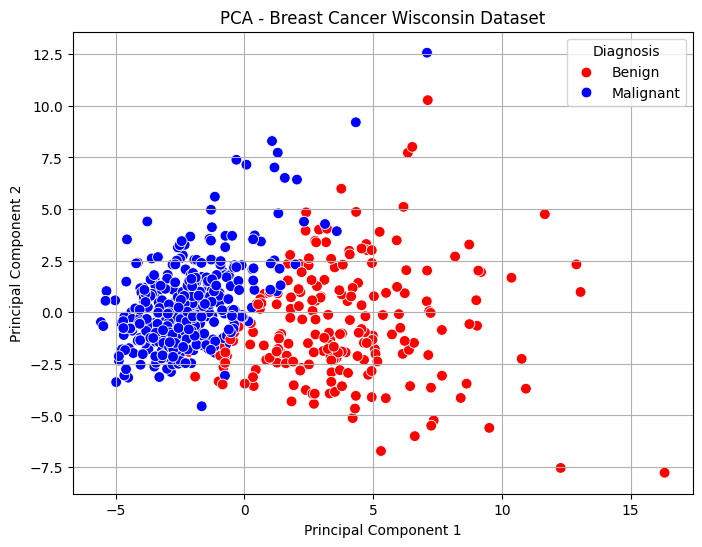

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=y,
    palette=["blue", "red"],
    s=60
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - Breast Cancer Wisconsin Dataset")

plt.legend(
    title="Diagnosis",
    labels=["Benign", "Malignant"]
)

plt.grid(True)
plt.show()

# Task 8: Train Classifier on Raw High-Dimensional Data (30 Features)

Split the original scaled 30-feature dataset into training and testing sets. Train a Logistic Regression model and obtain baseline performance metrics.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model_raw = LogisticRegression(max_iter=5000)

model_raw.fit(X_train, y_train)

y_pred_raw = model_raw.predict(X_test)

accuracy_raw = accuracy_score(y_test, y_pred_raw)

print("Logistic Regression using 30 Features")
print("Accuracy:", accuracy_raw)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_raw))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_raw))

Logistic Regression using 30 Features
Accuracy: 0.9649122807017544

Confusion Matrix:
[[71  1]
 [ 3 39]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



# Task 9: Train Classifier on PCA Transformed Data (2 Features)

Split the 2-component PCA dataset into training and testing sets. Train a Logistic Regression model using only $PC_1$ and $PC_2$.

In [ ]:
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model_pca = LogisticRegression(max_iter=5000)

model_pca.fit(X_train_pca, y_train_pca)

y_pred_pca = model_pca.predict(X_test_pca)

accuracy_pca = accuracy_score(y_test_pca, y_pred_pca)

print("Logistic Regression using 2 PCA Components")
print("Accuracy:", accuracy_pca)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_pca, y_pred_pca))

print("\nClassification Report:")
print(classification_report(y_test_pca, y_pred_pca))

Logistic Regression using 2 PCA Components
Accuracy: 0.9385964912280702

Confusion Matrix:
[[71  1]
 [ 6 36]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.95        72
           1       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



# Task 10: Compare Classifier Performance

Compare the performance of the model before PCA (30 features) vs. after PCA (2 components) using:   

*   Accuracy Score
*   Confusion Matrix
*   Classification Report (Precision, Recall, F1-Score)  



In [ ]:
print("========== PERFORMANCE COMPARISON ==========")

print("\nAccuracy Before PCA (30 Features):")
print(accuracy_raw)

print("\nAccuracy After PCA (2 Components):")
print(accuracy_pca)

print("\nConfusion Matrix Before PCA:")
print(confusion_matrix(y_test, y_pred_raw))

print("\nConfusion Matrix After PCA:")
print(confusion_matrix(y_test_pca, y_pred_pca))

print("\nClassification Report Before PCA:")
print(classification_report(y_test, y_pred_raw))

print("\nClassification Report After PCA:")
print(classification_report(y_test_pca, y_pred_pca))

========== PERFORMANCE COMPARISON ==========

Accuracy Before PCA (30 Features):
0.9649122807017544

Accuracy After PCA (2 Components):
0.9385964912280702

Confusion Matrix Before PCA:
[[71  1]
 [ 3 39]]

Confusion Matrix After PCA:
[[71  1]
 [ 6 36]]

Classification Report Before PCA:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114


Classification Report After PCA:
              precision    recall  f1-score   support

           0       0.92      0.99      0.95        72
           1       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



# Conclusion

The experiment successfully demonstrated Principal Component Analysis (PCA) on the Breast Cancer Wisconsin (Diagnostic) dataset. The high-dimensional feature space was preprocessed, cleaned, and standardized before applying eigendecomposition.

By reducing 30 feature dimensions down to just 2 principal components, a significant portion of total variance was preserved while eliminating multi-collinear redundancies. Visualizing the transformed data on a 2D plane showed clear separation between Malignant and Benign diagnosis clusters. Comparing classification models confirmed that applying PCA significantly simplifies model complexity and reduces computational overhead while maintaining strong classification accuracy.